In [326]:
from __future__ import print_function 
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
import random
from sklearn.datasets import fetch_openml
import os
import struct
from mnist.loader import MNIST
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
import time

In [327]:
!pip install python-mnist

In [328]:
mndata = MNIST('MNIST')
images, labels = mndata.load_training()
list_labels = list(labels)
def plot_image_index(list_labels, images, labels, number):
    plt.figure(figsize=(12, 6))
    labels_index = []
    for i in range(number):
        labels_index.append(list_labels.index(i))
        image_2d  = np.array(images[list_labels.index(i)]).reshape(28,28)
        plt.subplot(2, 5, i + 1)
        plt.imshow(image_2d, cmap='gray')
        plt.title(f"Index: {i} \nLabel: {labels[list_labels.index(i)]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

def label_index(list_labels):
    labels_index = []
    for i in range(10):
        labels_index.append(list_labels.index(i))
    return labels_index

label_index = label_index(list_labels)

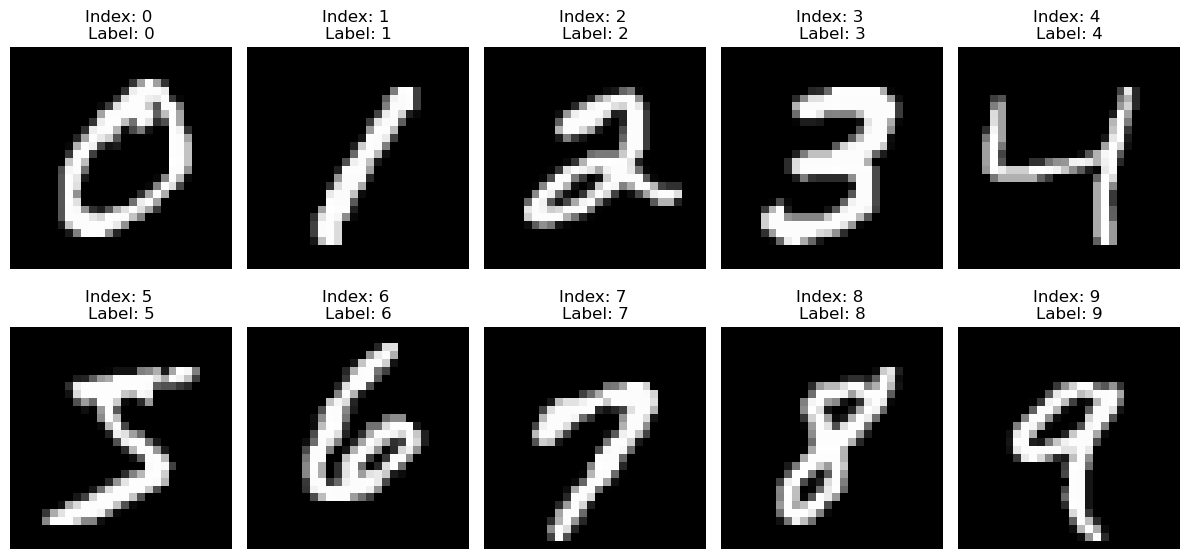

255


In [329]:
plot_image_index(list_labels, images, labels, 10)
print(np.max(images))

In [330]:
X_raw = np.array(images, dtype=float)
Y = np.array(labels)

print("Đã tải thành công tập dữ liệu huấn luyện!")
print("Kích thước mảng ảnh thô:", X_raw.shape)
images, labels = mndata.load_training()



Đã tải thành công tập dữ liệu huấn luyện!
Kích thước mảng ảnh thô: (60000, 784)


In [331]:
# Giảm chiều ma trận
X_flatten = X_raw.reshape(X_raw.shape[0], -1)

# Chuẩn hóa dữ liệu
from sklearn.preprocessing import normalize
X = normalize(X_flatten, norm='l2')
print(type(X))
print(type(Y))
print(X.shape)
print(Y.shape)

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
(60000, 784)
(60000,)


In [332]:
def label_to_onehot(Y):
    K = max(Y) + 1
    N = len(Y)
    result = np.zeros((N,K))
    for i in range(len(Y)):
        result[i][Y[i]] = 1
    return result

Y = label_to_onehot(Y)
print(Y)

[[0. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]]


In [333]:
def relu(z): 
    return np.maximum(0,z)

def softmax(z):
    return np.exp(z)/np.sum(np.exp(z),axis=0, keepdims=True) 

In [334]:
d = [784, 512, 128, 32, 10]
def feed_forward(X, W, b, d):
    """
    input:
    X: features (784,N)
    W: tập hợp L m trận
    L1 = 512, L2 = 128, L3 = 32, L4 = 10
    f2 = ReLu, f3 = ReLU, f4 = ReLu, f5 = Softmax
    """
    A = []
    Z = []
    a = X
    A.append(a)
    z = np.dot(W[0].T,a) + b[0]
    Z.append(z)
    for layer in range(1, len(d)-1):
        a = relu(z)
        A.append(a)
        z = np.dot(W[layer].T,a) + b[layer]
        Z.append(z)
    a_L = softmax(z)
    A.append(a_L)
    return a_L, A, Z

W = [
    np.random.uniform(0, 0.1, size=(784,512)),
    np.random.uniform(0, 0.1, size=(512,128)),
    np.random.uniform(0, 0.1, size=(128,32)),
    np.random.uniform(0, 0.1, size=(32,10)),
    ]

b = [np.zeros((d[i+1], 1)) for i in range(len(d)-1)]
y_hat, A, Z = feed_forward(X.T, W, b, [784, 512, 128, 32, 10])
print(y_hat.shape)
print(A)

(10, 60000)
[array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]]), array([[0.56743316, 0.58714663, 0.47274425, ..., 0.54753616, 0.5246577 ,
        0.48479005],
       [0.55500171, 0.57851856, 0.53697397, ..., 0.48421062, 0.55887448,
        0.52428628],
       [0.58517266, 0.62834737, 0.50084156, ..., 0.52663303, 0.52034565,
        0.49699675],
       ...,
       [0.59786677, 0.5577141 , 0.52378716, ..., 0.54847139, 0.51177641,
        0.524531  ],
       [0.52272451, 0.5569296 , 0.48070085, ..., 0.50153983, 0.4744535 ,
        0.48910284],
       [0.54709797, 0.58659567, 0.42339753, ..., 0.53432191, 0.51383424,
        0.51307221]]), array([[14.71027844, 15.63995942, 12.94153197, ..., 13.42184834,
        13.38777951, 13.45964624],
       [14.55712567, 15.45563316, 12.81798057, ..., 13.29066142,
  

In [335]:
def calculate_loss(y, y_hat, epsilon=1e-10):
    N = y.shape[1]
    return -np.sum(y * np.log(y_hat + epsilon)) / N
print(Y.shape)
J = calculate_loss(Y.T, y_hat, epsilon=1e-10)
print(J)

(60000, 10)
15.810661880624293


In [336]:
def backpropagation(W, A, y, Z):
    """
    input: w, A, b 
    - W: list(4 matrix)
    - A: list(4 vector)
    - b: list(4 vector bias)
    Output: gradient_w list (đạo hàm của J theo W từng layer)
            gradient_b list (đạo hàm của J theo b từng layer)

        dJ/dW_L = a_L-1 . (a_L - y)
        dJ/dB_L = a_L-y
        e_l = (W_l+1.e_l+1) * f'(z_l)
        dJ/dW_l = a_l-1 . e_l.T
        dJ/db_l = e_l
        
    """
    gradient_W = []
    gradient_b = []
    e_l = (A[-1] - y)/y.shape[1] # Kết quả của hàm softmax, chia N để nhất quán với loss
    for l in range(len(W)-1, -1, -1):
        gradient_W.append(np.dot(A[l], e_l.T))
        gradient_b.append(np.sum(e_l, axis=1, keepdims=True))

        if l > 0:
            e_l = np.dot(W[l], e_l) * (Z[l-1] > 0)
            # e_3 = (W_4 * e_4) * f'(z_3)     (đạo hàm của ReLU)
    gradient_W.reverse()
    gradient_b.reverse()
    return gradient_W, gradient_b

In [337]:
def gradient_descent(W, b, eta, gradient_W, gradient_b):
    for l in range(len(W)):
        W[l] -= eta * gradient_W[l]
        b[l] -= eta * gradient_b[l]
    return W, b

In [338]:
print(X.shape)
print(Y.shape)

(60000, 784)
(60000, 10)


In [339]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.30, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=42)
X_train, X_val, X_test = X_train.T, X_val.T, X_test.T
y_train, y_val, y_test = y_train.T, y_val.T, y_test.T

In [340]:
print(y_train)

[[0. 0. 0. ... 1. 1. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [342]:
def train(X_train, y_train, W, b, eta=0.01, epochs=5, d = [784, 512, 128, 32, 10]):
    """
    Input:
    - X: feature (784*N)
    - Y: Label (N*10)
    - W: list vector
    - b: list vector bias
    - d: number of layers 
    - learning rate
    - epochs

    -Output: 
    - W: list vector
    - b: list vector bias
    """
    for epoch in range(epochs):
        X_train, y_train = shuffle(X_train.T,y_train.T) # sklearn trộn theo hàng, nên phải Transfer
        X_train = X_train.T
        y_train = y_train.T
        for i in range(X_train.shape[1]):
            y_hat, A, Z = feed_forward(X_train, W, b,d)
            g_W, g_b = backpropagation(W, A, y_train, Z)
            W,b = gradient_descent(W, b, eta, g_W, g_b)
    return W, b


train(X_train, y_train, W, b, eta=0.01, epochs=5)

KeyboardInterrupt: 

In [ ]:
def onehot_to_label(Y):
    label = []
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]): 
            if Y[i,j] == 1:
                label.append(j)
    return np.array(label)

label_after_predict = onehot_to_label(Y)
print(label_after_predict)
print(M)

[5 0 4 ... 5 6 8]


NameError: name 'M' is not defined